In [2]:
import pandas as pd
import numpy as np
from typing import Dict, List
# from ydata_profiling import ProfileReport
from pathlib import Path
import requests
from io import BytesIO

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, HDBSCAN
from scipy.spatial.distance import cdist

from IPython.display import display

# **ETL**

In [3]:
def extract_apartment_sales(year: int = 2024) -> pd.DataFrame:
    """
    Pipeline ETL optimisé pour les transactions immobilières DVF.
    
    Optimisations Senior :
    - Early Projection : Suppression des colonnes inutiles AVANT l'étape coûteuse d'agrégation.
    - Vectorisation : Utilisation optimisée des masques booléens.
    - Typage Strict : Gestion robuste des types float32 pour diviser la RAM par 2.
    
    Args:
        year (int): Année cible.
        
    Returns:
        pd.DataFrame: Dataset consolidé (1 ligne = 1 Vente).
    """
    # --- 1. CONFIGURATION & CONSTANTES ---
    URL = f"https://files.data.gouv.fr/geo-dvf/latest/csv/{year}/full.csv.gz"
    
    # SCHEMA CIBLE (La colonne surface_terrain a été retirée)
    TARGET_SCHEMA = {
        'id_mutation': 'object',
        'valeur_fonciere': 'float32',
        'surface_reelle_bati': 'float32',
        'nombre_pieces_principales': 'float32',
        'code_commune': 'object',
        'latitude': 'float32',
        'longitude': 'float32'
    }
    
    print(f"🚀 [ETL] Démarrage du traitement DVF {year}...")
    print(f"⬇️  Stream : {URL}")

    try:
        # Chargement global (low_memory=False est nécessaire pour les fichiers mixtes DVF)
        df = pd.read_csv(URL, compression='gzip', low_memory=False)
    except Exception as e:
        print(f"❌ Erreur critique I/O : {e}")
        return pd.DataFrame()

    print(f"📊 Volume brut : {len(df):,} lignes.")

    # --- 2. FILTRAGE VECTORIEL (ROW FILTERING) ---
    print("🌍 Application des filtres métier (Vente / Appart / Métropole / GPS / Terrain)...")
    
    # Création des masques
    is_vente = df['nature_mutation'] == 'Vente'
    is_appart = df['type_local'] == 'Appartement'
    # Exclusion des codes départements 97X (DOM-TOM)
    is_metropole = ~df['code_departement'].astype(str).str.startswith('97', na=False)
    has_gps = df['latitude'].notna() & df['longitude'].notna()
    
    # On filtre sur le terrain pour garantir la typologie "Appart Standard"
    # mais la colonne sera supprimée juste après.
    terrain_clean = pd.to_numeric(df['surface_terrain'], errors='coerce').fillna(0)
    is_terrain_zero = (terrain_clean == 0)

    # Application du masque global (Optimisation .loc)
    df = df.loc[
        is_vente & is_appart & is_metropole & has_gps & is_terrain_zero
    ].copy()

    if df.empty:
        print("⚠️ Warning : Aucun enregistrement conservé après filtrage.")
        return df
        
    print(f"📉 Lignes conservées : {len(df):,}")

    # --- 3. DÉDOUBLONNAGE TECHNIQUE ---
    # On retire surface_terrain de la liste de vérification des doublons
    cols_doublons = [
        col for col in [
            "id_mutation", "valeur_fonciere", "type_local", 
            "surface_reelle_bati", "id_parcelle", 
            "lot1_numero", "adresse_numero", "adresse_nom_voie"
        ] if col in df.columns
    ]
    
    df.drop_duplicates(subset=cols_doublons, keep='first', inplace=True)
    print(f"🧹 Après dédoublonnage strict : {len(df):,} lignes.")

    # --- 4. PROJECTION COLONNAIRE (OPTIMISATION RAM) ---
    # On ne garde que les 7 colonnes définies dans TARGET_SCHEMA
    available_cols = [c for c in TARGET_SCHEMA.keys() if c in df.columns]
    df = df[available_cols]

    # --- 5. AGRÉGATION INTELLIGENTE ---
    print("∑  Agrégation des mutations (Group By)...")
    
    # Règles : 'sum' pour le bati, 'first' pour le reste (prix, gps, commune...)
    agg_rules = {col: 'first' for col in available_cols if col != 'id_mutation'}
    
    if 'surface_reelle_bati' in agg_rules:
        agg_rules['surface_reelle_bati'] = 'sum'
    
    # Le groupby est très rapide ici car il n'a plus de terrain ni colonnes inutiles
    df_final = df.groupby('id_mutation').agg(agg_rules).reset_index()

    # --- 6. CASTING & TYPAGE ---
    print("🎯 Conversion des types (Schema enforcement)...")
    
    for col, dtype in TARGET_SCHEMA.items():
        if col in df_final.columns:
            try:
                if 'float' in dtype:
                    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').astype(dtype)
                else:
                    df_final[col] = df_final[col].astype(dtype)
            except Exception as e:
                print(f"   ⚠️ Erreur typage {col}: {e}")

    # Réordonnancement final
    final_cols_ordered = [c for c in TARGET_SCHEMA.keys() if c in df_final.columns]
    df_final = df_final[final_cols_ordered]

    print(f"✅ Succès : {len(df_final):,} ventes uniques exportées.")
    return df_final

df = extract_apartment_sales(2024)

🚀 [ETL] Démarrage du traitement DVF 2024...
⬇️  Stream : https://files.data.gouv.fr/geo-dvf/latest/csv/2024/full.csv.gz
📊 Volume brut : 3,489,149 lignes.
🌍 Application des filtres métier (Vente / Appart / Métropole / GPS / Terrain)...
📉 Lignes conservées : 338,039
🧹 Après dédoublonnage strict : 334,812 lignes.
∑  Agrégation des mutations (Group By)...
🎯 Conversion des types (Schema enforcement)...
✅ Succès : 314,543 ventes uniques exportées.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314543 entries, 0 to 314542
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_mutation                314543 non-null  object 
 1   valeur_fonciere            314385 non-null  float32
 2   surface_reelle_bati        314543 non-null  float32
 3   nombre_pieces_principales  314495 non-null  float32
 4   code_commune               314543 non-null  object 
 5   latitude                   314543 non-null  float32
 6   longitude                  314543 non-null  float32
dtypes: float32(5), object(2)
memory usage: 10.8+ MB


# **EDA**

In [5]:
def generate_audit_report(df):
    report_dir = Path("..") / "reports"
    report_dir.mkdir(parents=True, exist_ok=True)
    
    print("🎲 Sélection d'un échantillon de 50 000 lignes...")
    df_sample = df.sample(50000, random_state=42)
    
    print("⚙️ Génération du rapport en cours... (Patience !)")
    profile = ProfileReport(
        df_sample, 
        title="Audit DVF 2024"
    )
    
    output_file = report_dir / "data_audit.html"
    profile.to_file(output_file)
    print(f"✅ Rapport sauvegardé : {output_file}")
    return profile

# profile = generate_audit_report(df)

# **Valeurs aberrantes**

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [7]:
def remove_statistical_outliers(
    df: pd.DataFrame, 
    cols_config: dict = None
) -> pd.DataFrame:
    """
    Filtre les valeurs aberrantes (outliers) en utilisant la méthode des centiles.
    
    Args:
        df (pd.DataFrame): Dataset propre.
        cols_config (dict): Dictionnaire {nom_colonne: (quantile_bas, quantile_haut)}.
                            Défaut: 1% - 99% pour surface et prix.
    
    Returns:
        pd.DataFrame: Dataset sans les extrêmes.
    """
    print(f"\n✂️ [OUTLIERS] Démarrage du filtrage statistique...")
    df_out = df.copy()
    initial_len = len(df_out)

    # Configuration par défaut si non fournie
    if cols_config is None:
        cols_config = {
            'surface_reelle_bati': (0.01, 0.99),        # On retire les studios minuscules et les châteaux
            'valeur_fonciere': (0.01, 0.99),            # On retire les ventes symboliques et les prix hors marché
            'nombre_pieces_principales': (0.01, 0.999)  # On retire les plateaux (0 pièce) et les châteaux aux 50 pièces
        }

    for col, (q_min, q_max) in cols_config.items():
        if col not in df_out.columns:
            print(f"   ⚠️ Colonne {col} absente, ignorée.")
            continue
            
        # Conversion numérique forcée (sécurité)
        df_out[col] = pd.to_numeric(df_out[col], errors='coerce')
        
        # Calcul des bornes
        low_bound = df_out[col].quantile(q_min)
        high_bound = df_out[col].quantile(q_max)
        
        # Création du masque
        if col == 'surface_terrain':
             mask = (df_out[col].isna()) | (df_out[col] <= high_bound)
        else:
             mask = (df_out[col] >= low_bound) & (df_out[col] <= high_bound)
        
        nb_removed = len(df_out) - mask.sum()
        
        print(f"   📏 {col:<20} : Gardé entre {low_bound:.1f} et {high_bound:.1f}. "
              f"Supprimés : {nb_removed} lignes.")
        
        df_out = df_out[mask]

    final_len = len(df_out)
    loss_pct = ((initial_len - final_len) / initial_len) * 100
    print(f"✅ Fin outliers. Lignes : {initial_len} -> {final_len} (Perte totale : {loss_pct:.2f}%)")
    
    return df_out

df_clean = remove_statistical_outliers(df)


✂️ [OUTLIERS] Démarrage du filtrage statistique...
   📏 surface_reelle_bati  : Gardé entre 14.0 et 176.0. Supprimés : 5557 lignes.
   📏 valeur_fonciere      : Gardé entre 21000.0 et 1161856.0. Supprimés : 6302 lignes.
   📏 nombre_pieces_principales : Gardé entre 1.0 et 6.0. Supprimés : 668 lignes.
✅ Fin outliers. Lignes : 314543 -> 302016 (Perte totale : 3.98%)


In [8]:
# profile = generate_audit_report(df_clean)

# **Feature Engineering**

In [9]:
def add_price_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Étape 1 : Création des variables financières de base.
    """
    print("💰 [FEATURES] Calcul du Prix au m²...")
    df_feat = df.copy()
    
    # Sécurité : On évite la division par zéro (même si peu probable après nettoyage)
    # On crée 'prix_m2'
    df_feat['prix_m2'] = df_feat['valeur_fonciere'] / df_feat['surface_reelle_bati']
    
    # Gestion des infinis si surface = 0 (cas rares résiduels)
    df_feat['prix_m2'] = df_feat['prix_m2'].replace([np.inf, -np.inf], np.nan)
    
    # On supprime les lignes où le prix_m2 n'a pas pu être calculé
    df_feat.dropna(subset=['prix_m2'], inplace=True)
    
    return df_feat

def add_local_market_context(df: pd.DataFrame) -> pd.DataFrame:
    """
    Étape 2 : Création du contexte de marché local (Data Leakage contrôlé).
    
    On calcule le prix médian de la commune À PARTIR du dataset lui-même.
    Cela permet au modèle de savoir si un bien est "cher" par rapport à ses voisins.
    """
    print("🏘️ [FEATURES] Calcul du contexte local (Prix médian par commune)...")
    
    # 1. Calcul du prix médian par commune
    # On utilise transform pour mapper directement la valeur sur chaque ligne
    median_price_by_city = df.groupby('code_commune')['prix_m2'].transform('median')
    
    df['marche_prix_m2_median'] = median_price_by_city

    return df

def categorize_zones(df: pd.DataFrame) -> pd.DataFrame:
    """
    Catégorisation des communes en 4 grands marchés immobiliers.
    """
    print("📍 [CATEGORIE] Segmentation Macro (Métropoles / Tourisme / IDF / Province)...")
    
    # 1. Extraction des codes départements (2 premiers chiffres)
    # On gère le cas des corses (2A/2B) automatiquement car c'est des strings
    df['dept'] = df['code_commune'].astype(str).str[:2]
    
    # --- DEFINITION DES LISTES ---
    
    # A. Les codes départements Île-de-France
    depts_idf = ['75', '92', '93', '94', '77', '78', '91', '95']
    
    # B. Les codes départements Littoral Fort / Montagne (Marchés tendus hors IDF)
    # 06(Nice), 13(Marseille-Aix), 33(Bordeaux), 83(Var), 74(Haute-Savoie), 69(Lyon-Rhone), 
    # 44(Nantes), 34(Montpellier), 2A/2B(Corse), 64(Pays Basque)
    depts_tourisme_tension = ['06', '13', '33', '83', '74', '69', '44', '34', '2A', '2B', '64', '35', '17']

    # C. Liste des Codes Insee des "Top Métropoles" (Pour cibler les hyper-centres)
    # Attention : Paris, Lyon, Marseille ont des codes par arrondissement (751xx, 693xx, 132xx)
    # On traitera ces cas via "startswith". Ici on met les autres grandes villes (codes uniques).
    # Toulouse, Nice, Nantes, Strasbourg, Montpellier, Bordeaux, Lille, Rennes
    top_villes_codes = ['31555', '06088', '44109', '67482', '34172', '33063', '59350', '35238']

    # --- LOGIQUE DE CLASSIFICATION (Ordre de priorité important) ---
    
    # Condition 1 : Est-ce une Top Métropole ?
    # -> Soit dans la liste explicite, soit un arrondissement de Paris/Lyon/Marseille
    is_metropole = (
        df['code_commune'].isin(top_villes_codes) | 
        df['code_commune'].str.startswith('751') |  # Paris Arrondissements
        df['code_commune'].str.startswith('693') |  # Lyon Arrondissements
        df['code_commune'].str.startswith('132')    # Marseille Arrondissements
    )
    
    # Condition 2 : Est-ce en Île-de-France (hors Paris déjà capté au dessus) ?
    is_idf = df['dept'].isin(depts_idf)
    
    # Condition 3 : Est-ce une zone Touristique/Tension (Littoral, Frontière suisse...) ?
    is_tourisme = df['dept'].isin(depts_tourisme_tension)
    
    # Construction du vecteur final avec np.select (équivalent Switch Case géant)
    conditions = [is_metropole, is_idf, is_tourisme]
    choices = ['1_Metropole_Top15', '2_Ile_de_France', '3_Zone_Touristique']
    
    # Tout le reste devient "4_Province_Standard"
    df['categorie_geo'] = np.select(conditions, choices, default='4_Province_Standard')
    
    # Nettoyage
    df.drop(columns=['dept'], inplace=True)
    
    print(f"   Répartition : {df['categorie_geo'].value_counts(normalize=True).round(2).to_dict()}")
    return df

def categorize_relative_standing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Classe le bien selon son positionnement prix vs le prix médian de sa commune.
    Permet d'identifier le 'Standing' relatif (Luxe, Standard, Travaux...) peu importe la ville.
    
    Segments :
    1. Décote (< 0.7) : Vente urgente ou gros travaux (-30%)
    2. Bonne Affaire (0.7 - 0.9) : Rafraichissement ou défaut (-10% à -30%)
    3. Standard (0.9 - 1.15) : Le cœur du marché (-10% à +15%)
    4. Premium (1.15 - 1.4) : Belles prestations (+15% à +40%)
    5. Prestige (> 1.4) : Exceptionnel ou hors marché (> +40%)
    """
    print("📊 [CATEGORIE] Segmentation du Standing (Ratio Prix/Commune)...")

    # Sécurité : On vérifie que les colonnes nécessaires existent
    if 'prix_m2' not in df.columns or 'marche_prix_m2_median' not in df.columns:
        print("   ⚠️ Colonnes prix manquantes. Saut de l'étape.")
        return df

    # Calcul du ratio temporaire
    # (Prix du bien / Prix médian de la ville)
    ratio = df['prix_m2'] / df['marche_prix_m2_median']

    # Définition des conditions (Seuils validés ensemble)
    conditions = [
        ratio < 0.70,                       # Décote forte
        (ratio >= 0.70) & (ratio < 0.90),   # Bas de fourchette
        (ratio >= 0.90) & (ratio < 1.15),   # Coeur de marché
        (ratio >= 1.15) & (ratio < 1.40),   # Haut de gamme
        ratio >= 1.40                       # Exception
    ]

    choices = [
        '1_Decote_Travaux',
        '2_Bonne_Affaire',
        '3_Standard_Marche',
        '4_Premium',
        '5_Prestige_Exception'
    ]

    # Application vectorielle
    df['standing_relative'] = np.select(conditions, choices, default='3_Standard_Marche')

    # Affichage de la répartition (Contrôle qualité)
    # On s'attend à une courbe en cloche (beaucoup de 3, un peu de 2/4, peu de 1/5)
    distrib = df['standing_relative'].value_counts(normalize=True).round(3).to_dict()
    # On trie le dictionnaire par clé pour l'affichage propre (1, 2, 3...)
    distrib_sorted = dict(sorted(distrib.items()))
    
    print(f"   Répartition : {distrib_sorted}")
    
    return df

def run_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline complet de Feature Engineering.
    """
    print("\n🛠️ [FEATURE ENGINEERING] Démarrage...")
    
    df = add_price_features(df)
    df = add_local_market_context(df)
    df = categorize_zones(df)
    df = categorize_relative_standing(df)
    
    print(f"✅ Terminé. Dataset enrichi : {df.shape[1]} colonnes.")
    return df

df_enrichi = run_feature_engineering(df_clean)


🛠️ [FEATURE ENGINEERING] Démarrage...
💰 [FEATURES] Calcul du Prix au m²...
🏘️ [FEATURES] Calcul du contexte local (Prix médian par commune)...
📍 [CATEGORIE] Segmentation Macro (Métropoles / Tourisme / IDF / Province)...
   Répartition : {'4_Province_Standard': 0.39, '3_Zone_Touristique': 0.23, '1_Metropole_Top15': 0.21, '2_Ile_de_France': 0.17}
📊 [CATEGORIE] Segmentation du Standing (Ratio Prix/Commune)...
   Répartition : {'1_Decote_Travaux': 0.131, '2_Bonne_Affaire': 0.214, '3_Standard_Marche': 0.366, '4_Premium': 0.186, '5_Prestige_Exception': 0.103}
✅ Terminé. Dataset enrichi : 11 colonnes.


In [10]:
df_enrichi.head(5)

,id_mutation,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,code_commune,latitude,longitude,prix_m2,marche_prix_m2_median,categorie_geo,standing_relative
0,2024-1000000,188000.0,68.0,4.0,83118,43.437805,6.775192,2764.705811,4960.866211,3_Zone_Touristique,1_Decote_Travaux
1,2024-1000005,295000.0,50.0,2.0,83036,43.169559,6.520398,5900.000000,5673.361816,3_Zone_Touristique,3_Standard_Marche
2,2024-1000006,333000.0,67.0,3.0,83118,43.427925,6.769402,4970.149414,4960.866211,3_Zone_Touristique,3_Standard_Marche
3,2024-1000007,163000.0,40.0,2.0,83061,43.433414,6.751504,4075.000000,4182.898438,3_Zone_Touristique,3_Standard_Marche
5,2024-1000010,244950.0,50.0,2.0,83061,43.387081,6.722440,4899.000000,4182.898438,3_Zone_Touristique,4_Premium


# **PCA**

In [11]:
def prepare_data_for_pca(df: pd.DataFrame):
    """
    Prépare les données pour la PCA :
    1. Sélection des colonnes numériques et ordinales.
    2. Encodage des catégories (ex: '1_Metropole' -> 1).
    3. Standardisation (Moyenne=0, Ecart-Type=1).
    
    Returns:
        X_scaled (np.array): Données prêtes.
        feature_names (list): Noms des colonnes dans l'ordre.
        df_encoded (pd.DataFrame): DataFrame intermédiaire (pour verification).
    """
    print("⚙️ [PCA] Préparation des données (Encoding + Scaling)...")
    
    # 1. Sélection des features
    # On exclut les IDs et le texte brut.
    # On inclut Lat/Lon car la position géographique joue sur les clusters.
    features_numeric = [
        'surface_reelle_bati', 'nombre_pieces_principales',
        'latitude', 'longitude', 'prix_m2'
    ]
    
    # Copie de travail
    df_pca = df[features_numeric].copy()
    
    # 3. Standardisation (Crucial pour la PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_pca)
    
    feature_names = df_pca.columns.tolist()
    
    return X_scaled, feature_names, df_pca

def run_pca_analysis(X_scaled, feature_names):
    """
    Exécute la PCA et affiche les contributions des variables aux 2 premières composantes.
    """
    print("🧮 [PCA] Calcul des composantes principales...")
    
    # On calcule toutes les composantes possibles (nombre de variables)
    n_components = len(feature_names)
    pca = PCA(n_components=n_components)
    X_projected = pca.fit_transform(X_scaled)
    
    # --- 1. Variance Expliquée ---
    var_ratio = pca.explained_variance_ratio_
    print(f"   📊 Variance expliquée par PC1 : {var_ratio[0]:.2%}")
    print(f"   📊 Variance expliquée par PC2 : {var_ratio[1]:.2%}")
    print(f"   📊 Total cumulé (PC1+PC2)   : {(var_ratio[0]+var_ratio[1]):.2%}")
    
    # --- 2. Analyse des Contributions (Loadings) ---
    # Les 'components_' sont les vecteurs propres. 
    # Une valeur élevée (positive ou négative) veut dire que la variable pèse lourd.
    
    df_loadings = pd.DataFrame(
        pca.components_.T, 
        index=feature_names, 
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    # On affiche le Top 3 contributeurs pour PC1 et PC2
    print("\n🔍 --- FACTEURS DETERMINANTS (TOP 3) ---")
    
    for i in range(2): # Pour PC1 et PC2
        pc_name = f'PC{i+1}'
        print(f"\n📌 Composante {pc_name} ({var_ratio[i]:.1%} variance) :")
        
        # On trie par valeur absolue pour voir les plus influents (positifs ou négatifs)
        sorted_loadings = df_loadings[pc_name].abs().sort_values(ascending=False)
        top_vars = sorted_loadings.head(4).index
        
        for var in top_vars:
            coef = df_loadings.loc[var, pc_name]
            direction = "➕ Augmente avec" if coef > 0 else "➖ Diminue avec"
            print(f"   • {var:<25} : {coef:+.2f} ({direction})")

    return pca, X_projected, df_loadings

def plot_pca_correlation_circle(pca, feature_names):
    """
    Affiche le Cercle des Corrélations (PC1 vs PC2).
    Permet de visualiser les relations entre variables.
    """
    # Coordonnées des variables sur les 2 premiers axes
    pcs = pca.components_
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Cercle unité
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    ax.add_artist(circle)
    
    # Flèches pour chaque variable
    for i, (x, y) in enumerate(zip(pcs[0, :], pcs[1, :])):
        # On trace la flèche
        ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, fc='red', ec='red')
        
        # On ajoute le texte (un peu décalé pour lisibilité)
        ax.text(x * 1.15, y * 1.15, feature_names[i], color='black', ha='center', va='center', fontsize=11, weight='bold')
    
    # Esthétique
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    ax.set_title("Cercle des Corrélations PCA (Variables Importantes)")
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Lignes centrales
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    
    plt.show()

⚙️ [PCA] Préparation des données (Encoding + Scaling)...
🧮 [PCA] Calcul des composantes principales...
   📊 Variance expliquée par PC1 : 38.00%
   📊 Variance expliquée par PC2 : 28.26%
   📊 Total cumulé (PC1+PC2)   : 66.25%

🔍 --- FACTEURS DETERMINANTS (TOP 3) ---

📌 Composante PC1 (38.0% variance) :
   • surface_reelle_bati       : +0.67 (➕ Augmente avec)
   • nombre_pieces_principales : +0.66 (➕ Augmente avec)
   • prix_m2                   : -0.33 (➖ Diminue avec)
   • latitude                  : -0.07 (➖ Diminue avec)

📌 Composante PC2 (28.3% variance) :
   • latitude                  : +0.71 (➕ Augmente avec)
   • longitude                 : -0.67 (➖ Diminue avec)
   • prix_m2                   : +0.15 (➕ Augmente avec)
   • nombre_pieces_principales : +0.12 (➕ Augmente avec)


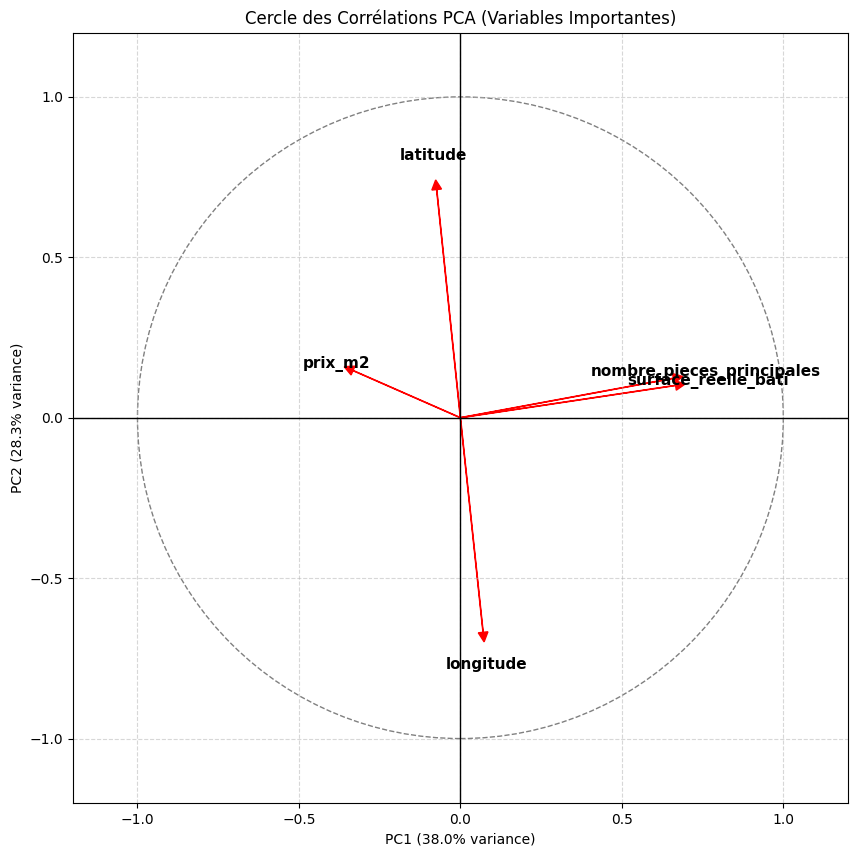

In [12]:
# 1. Préparation (Encoding + Scaling)
X_scaled, features, df_encoded = prepare_data_for_pca(df_enrichi)

# 2. Calcul et Analyse textuelle
pca, X_pca, df_loadings = run_pca_analysis(X_scaled, features)

# 3. Visualisation (Le Cercle)
plot_pca_correlation_circle(pca, features)

à revoir car on a supprimé les "variables de marché" : 
* ...

* ...

* ...

* ...

* ...

* ...

# **Sampling**

In [13]:
def create_master_sample(X_scaled, df_source, n_samples=40000):
    """
    Crée un échantillon représentatif fixe pour toute la suite de l'analyse.
    Génère les indices aléatoires et découpe à la fois :
    - Les données mathématiques (X_scaled) pour les algos.
    - Les données métier (df_source) pour les graphiques.
    
    Args:
        X_scaled (np.array): La matrice complète standardisée.
        df_source (pd.DataFrame): Le dataframe complet enrichi.
        n_samples (int): Taille cible (40k est un bon compromis).
        
    Returns:
        X_sample, df_sample
    """
    print(f"🎲 [SAMPLING] Création de l'échantillon maître ({n_samples} lignes)...")
    
    # 1. Génération d'indices aléatoires fixes (Random State 42 = Reproductibilité)
    # On tire au sort les numéros de lignes qu'on veut garder
    indices = resample(np.arange(len(X_scaled)), n_samples=n_samples, random_state=42)
    
    # 2. Découpage synchronisé
    X_sample = X_scaled[indices]
    df_sample = df_source.iloc[indices].copy()
    
    print(f"   ✅ Échantillon créé.")
    return X_sample, df_sample

def plot_representativity_check(df_full, df_sample):
    """
    Affiche la superposition des distributions (Full vs Sample)
    pour prouver la représentativité de l'échantillon.
    """
    print("📊 [CHECK] Génération des graphiques de preuve...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Variable 1 : Prix au m2 (Logique économique)
    # On utilise stat='density' pour que les hauteurs soient comparables 
    # (car le Full a 3M de lignes et le Sample 40k)
    sns.kdeplot(df_full['prix_m2'], color='blue', fill=True, alpha=0.1, label='Totalité (300k)', ax=axes[0])
    sns.kdeplot(df_sample['prix_m2'], color='red', linestyle='--', label='Échantillon (30k)', ax=axes[0])
    
    axes[0].set_title("Preuve 1 : Distribution du Prix m²")
    axes[0].set_xlim(0, df_full['prix_m2'].quantile(0.98)) # On coupe les valeurs extrêmes pour y voir clair
    axes[0].legend()
    
    # Variable 2 : Surface (Logique structurelle)
    sns.kdeplot(df_full['surface_reelle_bati'], color='green', fill=True, alpha=0.1, label='Totalité', ax=axes[1])
    sns.kdeplot(df_sample['surface_reelle_bati'], color='orange', linestyle='--', label='Échantillon', ax=axes[1])
    
    axes[1].set_title("Preuve 2 : Distribution des Surfaces")
    axes[1].set_xlim(0, 150) # Zoom sur les surfaces standards
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    print("   ✅ Graphiques affichés. Si les courbes se superposent, c'est gagné.")

🎲 [SAMPLING] Création de l'échantillon maître (10000 lignes)...
   ✅ Échantillon créé.
📊 [CHECK] Génération des graphiques de preuve...


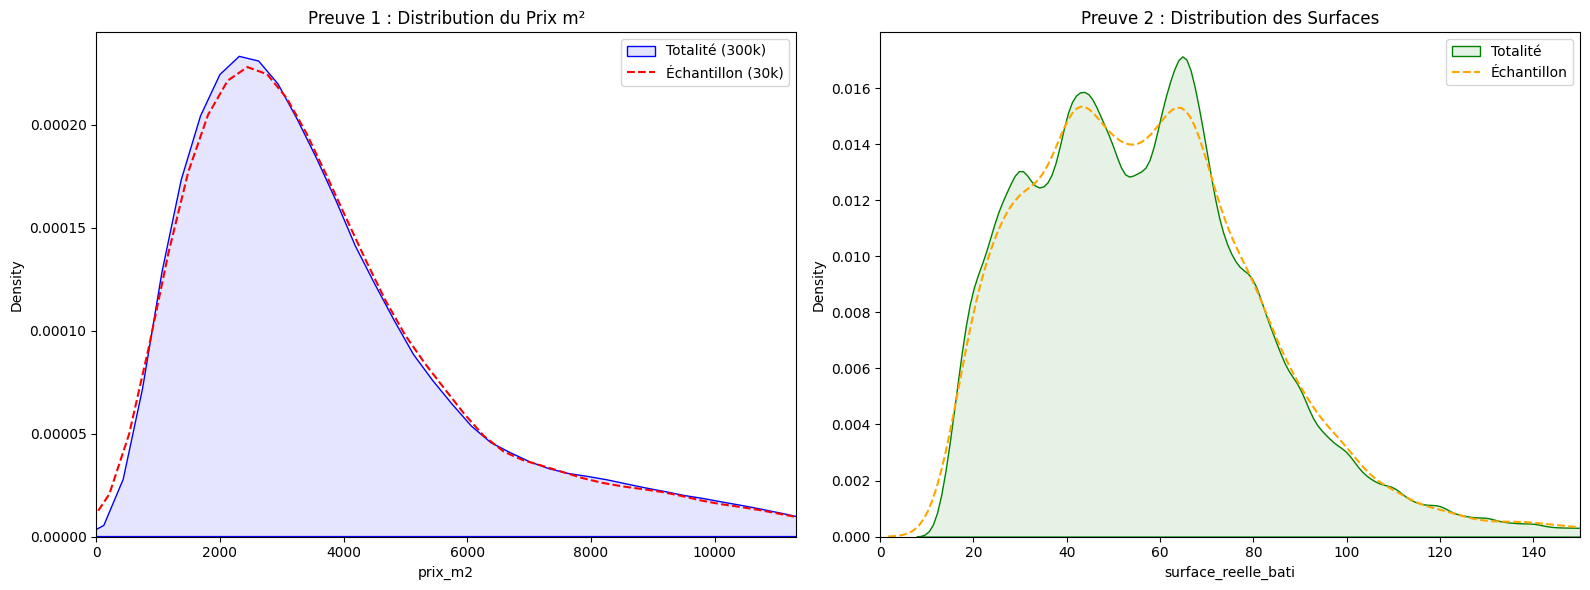

   ✅ Graphiques affichés. Si les courbes se superposent, c'est gagné.


In [14]:
# --- ÉTAPE CLÉ : CRÉATION DU MASTER SAMPLE ---
# On crée l'échantillon qui servira pour HDBSCAN, CAH et K-Means (comparaison équitable)
X_sample, df_sample = create_master_sample(X_scaled, df_enrichi, n_samples=10000)

# --- PREUVE VISUELLE POUR LE PROF ---
# Affiche ça dans ton notebook/rapport
plot_representativity_check(df_enrichi, df_sample)

# À partir de maintenant, TU NE TOUCHES PLUS à X_scaled complet pour le clustering lourd.
# Tu utilises X_sample.

# **KMEANS VS HDBSCAN VS CAH**

### **Voici les 4 métriques que nous allons utiliser**

- Silhouette Score ([-1 à 1], ⬆️ Haut = Mieux) : Qualité globale (Séparation + Cohésion). Biaisé vers les sphères, mais incontournable.

- Davies-Bouldin ([0 à ∞], ⬇️ Bas = Mieux) : Ratio de similitude entre clusters. Moins biaisé que Silhouette, mais préfère quand même les zones convexes.

- Calinski-Harabasz ([0 à ∞], ⬆️ Haut = Mieux) : Le "Variance Ratio". Il mesure si les clusters sont denses et bien séparés les uns des autres. C'est souvent le juge de paix quand Silhouette hésite.

- Distortion Moyenne ([0 à ∞], ⬇️ Bas = Mieux) : C'est la compacité pure. On calcule la distance moyenne entre chaque point et le centre de son cluster.

In [15]:
# --- 1. FONCTION DE CALCUL CENTRALISÉE ---
def calculate_advanced_metrics(X, labels, model_name, k, params=None):
    """
    Calcule les 4 métriques clés.
    Noms de colonnes standards (sans émojis) pour éviter les bugs.
    """
    # Masque pour ignorer le bruit (important pour HDBSCAN)
    mask = labels != -1
    X_clean = X[mask]
    labels_clean = labels[mask]
    
    # Sécurité
    if len(set(labels_clean)) < 2 or len(X_clean) < 100:
        return {
            "Model": model_name, "Clusters (k)": len(set(labels_clean)),
            "Silhouette": 0, "Davies_Bouldin": 999,
            "Calinski_Harabasz": 0, "Distortion": 999
        }

    # Calculs
    sil = silhouette_score(X_clean, labels_clean)
    db = davies_bouldin_score(X_clean, labels_clean)
    ch = calinski_harabasz_score(X_clean, labels_clean)
    
    # Distortion (Maison)
    distortion_sum = 0
    unique_labs = set(labels_clean)
    for l in unique_labs:
        cluster_points = X_clean[labels_clean == l]
        centroid = cluster_points.mean(axis=0).reshape(1, -1)
        dists = cdist(cluster_points, centroid, metric='euclidean')
        distortion_sum += dists.sum()
    
    avg_distortion = distortion_sum / len(X_clean)

    # Noms de colonnes SIMPLES (Pas d'émojis ici pour éviter KeyError)
    metrics = {
        "Model": model_name,
        "Clusters (k)": int(k),
        "Silhouette": round(sil, 3),
        "Davies_Bouldin": round(db, 3),
        "Calinski_Harabasz": int(ch),
        "Distortion": round(avg_distortion, 3)
    }
    
    if params:
        metrics.update(params)
        
    return metrics

# --- 2. K-MEANS ---
def run_kmeans_benchmark_v2(X_sample: np.ndarray, k_values: list = [4, 5, 6, 7]) -> pd.DataFrame:
    print(f"🏗️ [K-MEANS] Benchmark Multi-Métriques...")
    results = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = model.fit_predict(X_sample)
        metrics = calculate_advanced_metrics(X_sample, labels, "K-Means", k)
        results.append(metrics)
    return pd.DataFrame(results).set_index("Clusters (k)")

# --- 3. HDBSCAN ---
def run_hdbscan_epsilon_search_v2(X_sample: np.ndarray, target_k_range: tuple = (5, 7)) -> tuple[pd.DataFrame, np.ndarray]:
    print(f"🔧 [HDBSCAN] Recherche Epsilon...")
    fixed_min_size = 60
    epsilon_grid = np.linspace(0.0, 1.2, 40)
    candidates = []

    for eps in epsilon_grid:
        model = HDBSCAN(min_cluster_size=fixed_min_size, cluster_selection_epsilon=eps, metric='euclidean')
        labels = model.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if target_k_range[0] <= n_clusters <= target_k_range[1]:
            metrics = calculate_advanced_metrics(
                X_sample, labels, "HDBSCAN", n_clusters, 
                params={"Param_Epsilon": round(eps, 3), "Noise_Ratio": round((labels==-1).mean(), 3)}
            )
            metrics['labels'] = labels 
            candidates.append(metrics)

    if candidates:
        # Tri par Silhouette
        best_metric_dict = sorted(candidates, key=lambda x: x['Silhouette'], reverse=True)[0]
        best_labels = best_metric_dict.pop('labels')
        df_res = pd.DataFrame([best_metric_dict]).set_index("Model")
        return df_res, best_labels
    else:
        print("⚠️ Aucun candidat trouvé.")
        return pd.DataFrame(), np.zeros(len(X_sample))
    
# --- 4. CAH (HIERARCHICAL) ---
def run_cah_benchmark_v2(X_sample: np.ndarray, target_k: int = 6) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Exécute la CAH (Méthode Ward), affiche le dendrogramme et calcule les 4 métriques.
    Coupe l'arbre pour obtenir exactement 'target_k' clusters.
    """
    print(f"🧬 [CAH] Calcul de la matrice de lien (Ward) sur {len(X_sample)} points...")
    
    # 1. Matrice de lien (Lourd en calcul O(N^2))
    # Ward minimise la variance intra-cluster (similaire à la logique K-Means)
    Z = linkage(X_sample, method='ward')
    
    # 2. Affichage du Dendrogramme (Tronqué pour lisibilité)
    plt.figure(figsize=(10, 5))
    plt.title(f"Dendrogramme CAH (Ward) - Coupe à {target_k} clusters")
    plt.xlabel("Index (Regroupés)")
    plt.ylabel("Distance de Ward")
    
    dendrogram(
        Z,
        truncate_mode='lastp',  # On ne montre que les dernières branches
        p=30,                   # Nombre de branches finales affichées
        leaf_rotation=90.,
        leaf_font_size=10.,
        show_contracted=True
    )
    plt.show()
    
    # 3. Coupe de l'arbre
    print(f"✂️  Découpe de l'arbre pour {target_k} clusters...")
    # criterion='maxclust' force l'algo à trouver la hauteur de coupe pour avoir k clusters
    labels = fcluster(Z, t=target_k, criterion='maxclust')
    
    # Scipy commence les labels à 1, on décale à 0 pour être standard
    labels = labels - 1
    
    # 4. Calcul des métriques centralisées
    metrics = calculate_advanced_metrics(X_sample, labels, "CAH (Ward)", target_k)
    
    df_res = pd.DataFrame([metrics]).set_index("Model")
    return df_res, labels

🏗️ [K-MEANS] Benchmark Multi-Métriques...
🔧 [HDBSCAN] Recherche Epsilon...
🧬 [CAH] Calcul de la matrice de lien (Ward) sur 10000 points...


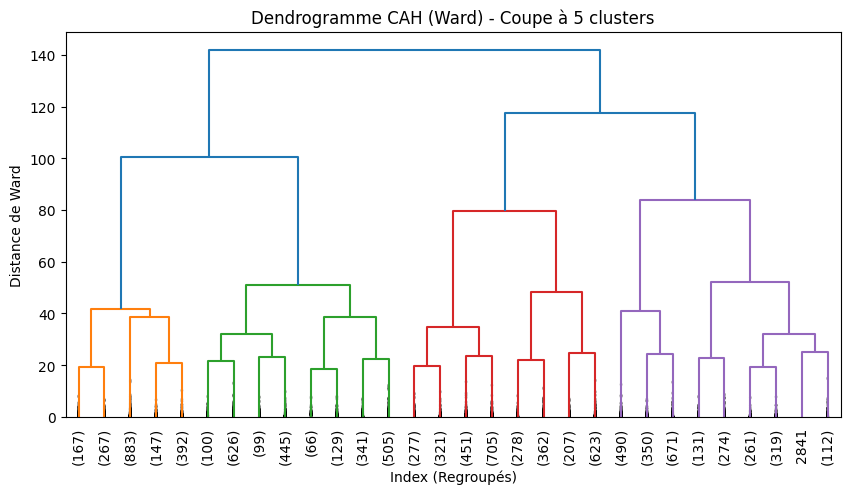

✂️  Découpe de l'arbre pour 5 clusters...

🏆 PODIUM FINAL DES MODÈLES :


,Clusters (k),Silhouette,Davies_Bouldin,Calinski_Harabasz,Distortion
Model,,,,,
K-Means,5,0.260,1.251,3220,1.361
CAH (Ward),5,0.214,1.309,2592,1.424
HDBSCAN,5,0.055,2.231,965,1.486


In [16]:
# 1. K-MEANS (Test 4, 5, 6, 7)
df_kmeans = run_kmeans_benchmark_v2(X_sample, k_values=[4, 5, 6, 7])

# 2. HDBSCAN (Cherche le meilleur entre 5 et 7)
df_hdbscan, hdbscan_labels = run_hdbscan_epsilon_search_v2(X_sample, target_k_range=(5, 7))

# 3. CAH (On aligne le k sur celui trouvé par HDBSCAN pour comparer, ou 6 par défaut)
if not df_hdbscan.empty:
    target_k_cah = df_hdbscan["Clusters (k)"].iloc[0]
else:
    target_k_cah = 6 # Valeur médiane par défaut

df_cah, cah_labels = run_cah_benchmark_v2(X_sample, target_k=target_k_cah)

# --- 4. TABLEAU FINAL ---
print("\n🏆 PODIUM FINAL DES MODÈLES :")

# On prépare la ligne K-Means correspondante au même k que les autres
row_kmeans = df_kmeans[df_kmeans.index == target_k_cah].copy()
row_kmeans["Model"] = "K-Means"
row_kmeans = row_kmeans.reset_index().set_index("Model")

# Concaténation propre (toutes les colonnes ont le même nom maintenant)
df_final = pd.concat([
    row_kmeans, 
    df_cah,
    df_hdbscan.drop(columns=['Param_Epsilon', 'Noise_Ratio'], errors='ignore') # On nettoie pour l'affichage comparatif
])

# Tri par Silhouette pour voir le gagnant
df_final = df_final.sort_values("Silhouette", ascending=False)

display(df_final)

# **Visualisation des clusters**

In [17]:
# --- PRÉPARATION DES LABELS POUR LA CARTE ---
# On s'assure que df_sample contient bien les clusters des 3 modèles

# 1. K-Means (On re-calcule vite fait pour le meilleur k identifié, ex: 6)
# (C'est très rapide sur 40k lignes)

best_k = int(target_k_cah) # On s'aligne sur le k commun (ex: 6)
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
df_sample['cluster_kmeans'] = kmeans_model.fit_predict(X_sample)

# 2. HDBSCAN (On a déjà les labels dans hdbscan_labels)
df_sample['cluster_hdbscan'] = hdbscan_labels

# 3. CAH (On a déjà les labels dans cah_labels)
df_sample['cluster_cah'] = cah_labels

In [18]:
def plot_france_clusters(df, title_suffix=""):
    """
    Affiche 3 cartes de France côte à côte (K-Means, HDBSCAN, CAH).
    Style 'Dark Background' pour un effet visuel moderne.
    """
    print("🗺️ [VISUALISATION] Génération des cartes de France...")
    
    # On active le style sombre temporairement
    with plt.style.context('dark_background'):
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))
        fig.suptitle(f"Comparaison Géographique des Clusters {title_suffix}", fontsize=20, color='white')

        # Liste des configs pour la boucle
        configs = [
            ("K-Means", 'cluster_kmeans'),
            ("HDBSCAN", 'cluster_hdbscan'),
            ("CAH (Ward)", 'cluster_cah')
        ]

        for i, (model_name, col_name) in enumerate(configs):
            ax = axes[i]
            
            # Gestion spéciale HDBSCAN : On sépare le bruit (-1) des clusters
            if model_name == "HDBSCAN":
                # 1. D'abord le bruit en arrière-plan (Gris discret)
                noise = df[df[col_name] == -1]
                ax.scatter(noise['longitude'], noise['latitude'], 
                           c='#333333', s=1, alpha=0.3, label='Bruit')
                
                # 2. Ensuite les clusters par dessus
                data = df[df[col_name] != -1]
                scatter = ax.scatter(data['longitude'], data['latitude'], 
                                     c=data[col_name], cmap='rainbow', s=2, alpha=0.8)
            else:
                # Pour K-Means et CAH (pas de bruit)
                scatter = ax.scatter(df['longitude'], df['latitude'], 
                                     c=df[col_name], cmap='rainbow', s=2, alpha=0.8)

            # Esthétique de la carte
            ax.set_title(f"{model_name}", fontsize=15, color='white')
            ax.axis('off') # On enlève les axes Lat/Lon (moches)
            ax.set_aspect('equal') # IMPORTANT : Pour ne pas déformer la France
            
            # Petit trick : Limites fixes pour centrer sur la France métropolitaine
            # (Au cas où tu aurais des DOM-TOM qui écrasent l'échelle)
            ax.set_xlim(-5, 10)
            ax.set_ylim(41, 52)

        plt.tight_layout()
        plt.show()

🗺️ [VISUALISATION] Génération des cartes de France...


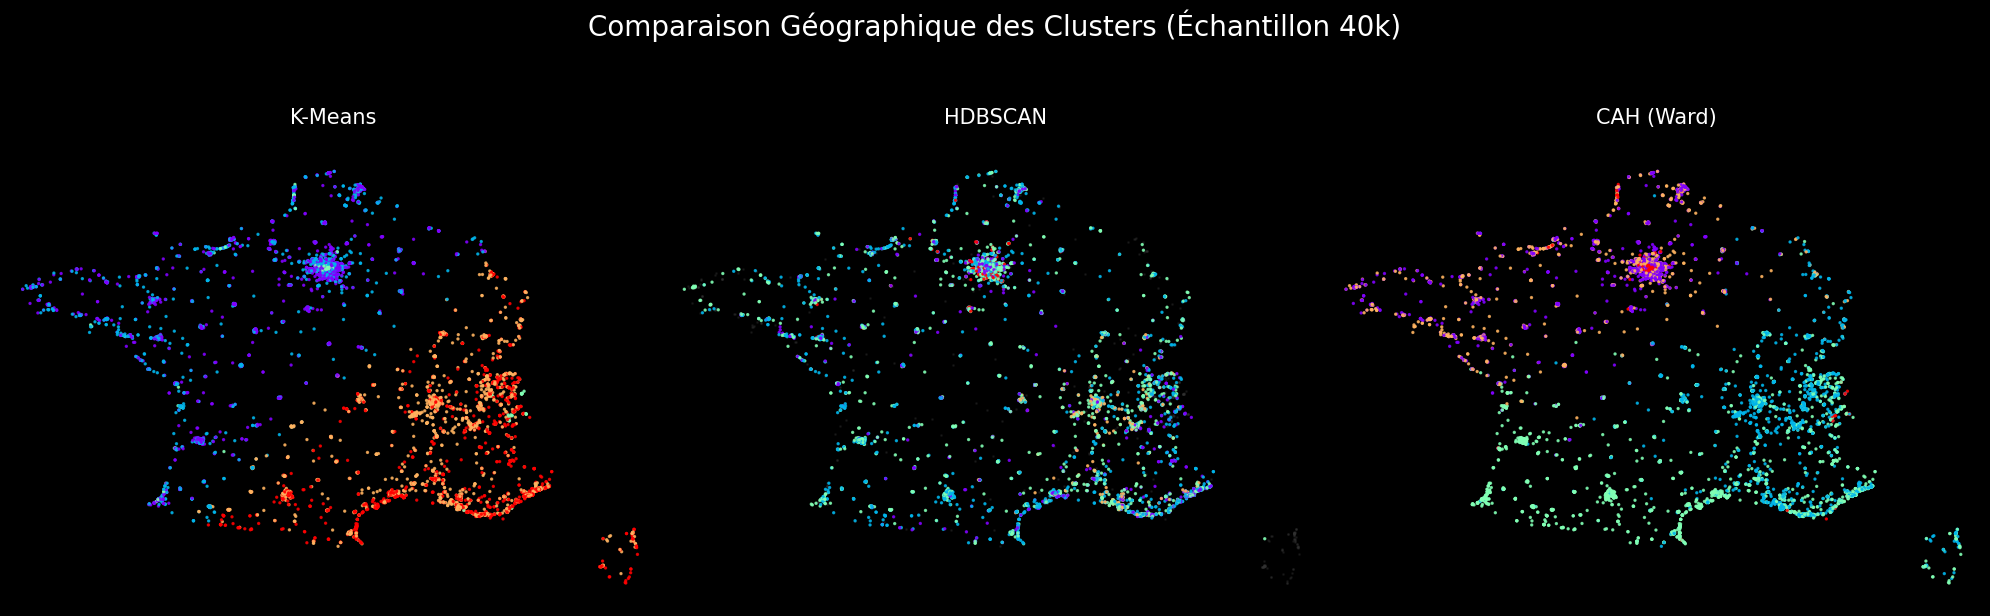

In [19]:
plot_france_clusters(df_sample, title_suffix="(Échantillon 40k)")

In [20]:
def display_cluster_profiles(df_sample, num_features=None, cat_features=None):
    """
    Affiche un tableau de bord complet pour chaque cluster :
    - Moyenne pour les variables numériques (Prix, Surface...)
    - "Top Catégorie" pour les variables textuelles (Zone, Standing...)
    """
    print("📊 [INTERPRÉTATION] Profilage Mixte (Moyennes + Catégories Dominantes)...")
    
    # 1. Définition des variables par défaut
    if num_features is None:
        num_features = [
            'prix_m2', 
            'surface_reelle_bati', 
            'nombre_pieces_principales', 
            'marche_prix_m2_median'
        ]
        
    if cat_features is None:
        # On ajoute tes variables catégorielles créées plus tôt
        cat_features = [
            'categorie_geo',       # ex: 1_Metropole, 4_Province...
            'standing_relative'    # ex: 3_Standard, 5_Prestige...
        ]
    
    # Sécurité : on ne garde que ce qui existe vraiment dans le dataframe
    valid_num = [f for f in num_features if f in df_sample.columns]
    valid_cat = [f for f in cat_features if f in df_sample.columns]
    
    # Dictionnaire des modèles
    models = {
        'K-Means': 'cluster_kmeans',
        'HDBSCAN': 'cluster_hdbscan',
        'CAH (Ward)': 'cluster_cah'
    }

    for model_name, col_name in models.items():
        if col_name not in df_sample.columns:
            continue
            
        print(f"\n🔹 --- PROFILAGE : {model_name} ---")
        
        # 2. Construction du Dictionnaire d'Agrégation
        # Pour les numériques -> 'mean'
        agg_dict = {col: 'mean' for col in valid_num}
        
        # Pour les catégorielles -> Une fonction custom qui renvoie la valeur la plus fréquente (Mode)
        def get_top_category(series):
            return series.mode().iloc[0] if not series.empty else "N/A"
            
        for col in valid_cat:
            agg_dict[col] = get_top_category
            
        # 3. GroupBy & Aggregation
        profile = df_sample.groupby(col_name).agg(agg_dict)
        
        # 4. Ajout des Volumes (Indispensable pour juger le poids du cluster)
        counts = df_sample[col_name].value_counts()
        profile.insert(0, 'Nb_Biens', counts) # On met ça en 1ère colonne
        profile.insert(1, '%_Total', (counts / len(df_sample) * 100))
        
        # 5. Tri Intelligent (Basé sur le prix pour avoir une échelle logique)
        if 'prix_m2' in profile.columns:
            profile = profile.sort_values('prix_m2')
            
        # 6. Gestion du Bruit HDBSCAN
        if -1 in profile.index:
            profile = profile.rename(index={-1: '⚠️ BRUIT'})

        # 7. Affichage Stylisé (Heatmap uniquement sur les chiffres)
        # On formate les pourcentages et les grands nombres
        styled = profile.style.background_gradient(cmap='YlOrRd', subset=valid_num)\
                        .bar(subset=['%_Total'], color='#5fba7d', vmin=0, vmax=100)\
                        .format("{:.0f}", subset=[c for c in ['Nb_Biens', 'prix_m2', 'marche_prix_m2_median'] if c in profile.columns])\
                        .format("{:.1f}", subset=['%_Total', 'surface_reelle_bati', 'nombre_pieces_principales'])\
        
        display(styled)

In [21]:
display_cluster_profiles(df_sample)

📊 [INTERPRÉTATION] Profilage Mixte (Moyennes + Catégories Dominantes)...

🔹 --- PROFILAGE : K-Means ---


,Nb_Biens,%_Total,prix_m2,surface_reelle_bati,nombre_pieces_principales,marche_prix_m2_median,categorie_geo,standing_relative
cluster_kmeans,,,,,,,,
3,2513,25.1,2812,78.0,3.5,2929,4_Province_Standard,3_Standard_Marche
0,2259,22.6,3118,76.0,3.5,3424,4_Province_Standard,3_Standard_Marche
1,1944,19.4,3475,38.5,1.7,3414,4_Province_Standard,3_Standard_Marche
4,2364,23.6,3701,38.2,1.7,3471,3_Zone_Touristique,3_Standard_Marche
2,920,9.2,9835,44.0,2.1,8685,1_Metropole_Top15,3_Standard_Marche



🔹 --- PROFILAGE : HDBSCAN ---


,Nb_Biens,%_Total,prix_m2,surface_reelle_bati,nombre_pieces_principales,marche_prix_m2_median,categorie_geo,standing_relative
cluster_hdbscan,,,,,,,,
3,471,4.7,2538,78.9,4.0,2855,4_Province_Standard,3_Standard_Marche
2,2693,26.9,3314,64.0,3.0,3459,4_Province_Standard,3_Standard_Marche
4,316,3.2,3497,79.4,4.0,3864,2_Ile_de_France,2_Bonne_Affaire
1,2752,27.5,3970,42.9,2.0,3927,4_Province_Standard,3_Standard_Marche
⚠️ BRUIT,2331,23.3,4377,78.2,3.2,3979,4_Province_Standard,3_Standard_Marche
0,1437,14.4,4391,27.0,1.0,4151,4_Province_Standard,3_Standard_Marche



🔹 --- PROFILAGE : CAH (Ward) ---


,Nb_Biens,%_Total,prix_m2,surface_reelle_bati,nombre_pieces_principales,marche_prix_m2_median,categorie_geo,standing_relative
cluster_cah,,,,,,,,
0,1856,18.6,2881,73.5,3.4,3229,4_Province_Standard,3_Standard_Marche
1,2311,23.1,2978,79.6,3.5,3067,4_Province_Standard,3_Standard_Marche
3,1511,15.1,3319,39.0,1.7,3273,4_Province_Standard,3_Standard_Marche
2,3224,32.2,3500,43.9,2.0,3330,3_Zone_Touristique,3_Standard_Marche
4,1098,11.0,9231,47.8,2.2,8350,1_Metropole_Top15,3_Standard_Marche


# Isolation Forest

In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def fit_isolation_forest_opportunities(
    df: pd.DataFrame,
    contamination: float = 0.02,
    n_estimators: int = 500,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Détecte des anomalies contextuelles (opportunités potentielles) via Isolation Forest.

    Sorties ajoutées au DataFrame:
    - ratio_prix_marche : prix_m2 / median_local
    - anomaly_label : 1 normal, -1 anomalie
    - anomaly_score : score_samples (plus faible => plus anormal)

    Hypothèses:
    - df contient prix_m2, marche_prix_m2_median, surface_reelle_bati, nombre_pieces_principales
    """

    required = ["prix_m2", "marche_prix_m2_median", "surface_reelle_bati", "nombre_pieces_principales"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes: {missing}")

    out = df.copy()

    # 1) Feature clé : décote vs marché local
    out["ratio_prix_marche"] = out["prix_m2"] / out["marche_prix_m2_median"]
    out.replace([np.inf, -np.inf], np.nan, inplace=True)

    feature_cols = [
        "surface_reelle_bati",
        "nombre_pieces_principales",
        "prix_m2",
        "marche_prix_m2_median",
        "ratio_prix_marche"
    ]

    # 2) Filtrage strict des lignes utilisables
    mask = out[feature_cols].notna().all(axis=1)
    X = out.loc[mask, feature_cols].astype("float32")

    # 3) Standardisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4) Modèle
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_scaled)

    # 5) Sorties
    out.loc[mask, "anomaly_label"] = model.predict(X_scaled)
    out.loc[mask, "anomaly_score"] = model.score_samples(X_scaled)

    # Harmonisation types
    out["anomaly_label"] = out["anomaly_label"].astype("Int64")

    return out


In [23]:
def get_top_opportunities(df: pd.DataFrame, top_k: int = 200, ratio_max: float = 0.85) -> pd.DataFrame:
    """
    Extrait les meilleures opportunités :
    - anomalies (label=-1)
    - décote significative (ratio_prix_marche < ratio_max)
    Classement: ratio croissant puis score croissant.
    """
    cols = [
        "valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales",
        "prix_m2", "marche_prix_m2_median", "ratio_prix_marche",
        "categorie_geo", "standing_relative", "latitude", "longitude",
        "anomaly_score"
    ]
    cols = [c for c in cols if c in df.columns]

    opp = df.query("anomaly_label == -1 and ratio_prix_marche < @ratio_max").copy()
    opp = opp.sort_values(["ratio_prix_marche", "anomaly_score"], ascending=[True, True])
    return opp[cols].head(top_k)

In [24]:
df_if = fit_isolation_forest_opportunities(df_enrichi, contamination=0.02)
df_if["anomaly_label"].value_counts(normalize=True)

anomaly_label
1     0.979998
-1    0.020002
Name: proportion, dtype: Float64

In [25]:
df_if.groupby("anomaly_label")[["prix_m2", "ratio_prix_marche", "surface_reelle_bati"]].median()

,prix_m2,ratio_prix_marche,surface_reelle_bati
anomaly_label,,,
-1,11093.750000,1.223339,68.0
1,3175.257812,1.000000,55.0


Isolation Forest identifie en priorité des biens fortement atypiques, caractérisés par un prix au m² significativement supérieur au marché local.

Un bien à fort potentiel est un bien qui :

Est significativement sous-évalué par rapport à son marché local

Est structurellement exploitable (surface, typologie)

Est situé dans un marché porteur (zone tendue / touristique / métropole)

In [37]:
def score_decote(ratio):
    if ratio < 0.30:
        ratio = 0.30
    return (1 - ratio) * 100

Si le bien vaut moins de 30 % du prix normal, on le traite comme 30 %, afin d'éviter les opportunités trop extrêmes

In [30]:
def score_surface(surface):
    if surface < 25 or surface > 200:
        return 30  # pénalité légère uniquement
    return 100 - abs(surface - 90)

In [31]:
def score_zone(cat):
    return {
        '1_Metropole_Top15': 100,
        '3_Zone_Touristique': 95,
        '2_Ile_de_France': 90,
        '4_Province_Standard': 80
    }.get(cat, 75)

In [32]:
def score_anomaly(anomaly_score, s_min, s_max):
    # Inversion : plus négatif = plus fort
    return ((s_max - anomaly_score) / (s_max - s_min)) * 100

In [38]:
def compute_investment_score_no_bias(df):
    df = df.copy()

    df['score_decote'] = df['ratio_prix_marche'].apply(score_decote)
    df['score_surface'] = df['surface_reelle_bati'].apply(score_surface)
    df['score_zone'] = df['categorie_geo'].apply(score_zone)

    s_min, s_max = df['anomaly_score'].min(), df['anomaly_score'].max()
    df['score_anomaly'] = df['anomaly_score'].apply(
        lambda x: score_anomaly(x, s_min, s_max)
    )

    df['investment_score'] = (
        0.45 * df['score_decote'] +
        0.20 * df['score_surface'] +
        0.20 * df['score_zone'] +
        0.15 * df['score_anomaly']
    )

    return df

In [39]:
candidates = df_if.query(
    "anomaly_label == -1 and ratio_prix_marche < 0.85"
)

In [40]:
ranked = compute_investment_score_no_bias(candidates)

top_investments = ranked.sort_values(
    'investment_score', ascending=False
).head(50)

In [41]:
top_investments[
    [
        'investment_score',
        'ratio_prix_marche',
        'prix_m2',
        'marche_prix_m2_median',
        'surface_reelle_bati',
        'categorie_geo',
        'anomaly_score'
    ]
]

,investment_score,ratio_prix_marche,prix_m2,marche_prix_m2_median,surface_reelle_bati,categorie_geo,anomaly_score
93249,76.503987,0.120727,1219.589966,10102.041016,100.0,1_Metropole_Top15,-0.681396
82933,75.800579,0.079945,1071.428589,13402.126953,112.0,1_Metropole_Top15,-0.697765
83155,75.460315,0.084247,1055.555542,12529.314453,90.0,1_Metropole_Top15,-0.652031
65891,75.347919,0.037449,388.888885,10384.444336,90.0,1_Metropole_Top15,-0.650946
72447,75.155890,0.022761,236.363632,10384.444336,110.0,1_Metropole_Top15,-0.687686
77160,74.943083,0.026125,297.619049,11392.000000,84.0,1_Metropole_Top15,-0.658618
74887,74.938046,0.058494,478.260864,8176.275391,92.0,1_Metropole_Top15,-0.650851
71598,74.938046,0.058494,478.260864,8176.275391,92.0,1_Metropole_Top15,-0.650851
89060,74.919099,0.031293,354.197906,11318.609375,96.0,1_Metropole_Top15,-0.658387
88845,74.735657,0.124924,1565.217407,12529.314453,115.0,1_Metropole_Top15,-0.693279


Essayons plusieurs contamination

In [46]:
contaminations = [0.01, 0.02, 0.03,0.04,0.05,0.06]
results = []

for c in contaminations:
    df_test = fit_isolation_forest_opportunities(
        df_enrichi,
        contamination=c,
        random_state=42
    )

    total = len(df_test)

    # Seuil dynamique pour le score d'anomalie
    anomaly_threshold = df_test["anomaly_score"].quantile(0.25)

    opportunities = df_test[
        (df_test["anomaly_label"] == -1) &
        (df_test["ratio_prix_marche"] <= 0.70) &
        (df_test["surface_reelle_bati"].between(50, 150)) &
        (df_test["anomaly_score"] <= anomaly_threshold)
    ]

    nb_opportunities = len(opportunities)
    pct_opportunities = nb_opportunities / total * 100

    results.append({
        "contamination": c,
        "nb_opportunities": nb_opportunities,
        "pct_opportunities": round(pct_opportunities, 2)
    })

df_opportunity_comparison = pd.DataFrame(results)
df_opportunity_comparison


,contamination,nb_opportunities,pct_opportunities
0,0.01,301,0.10
1,0.02,643,0.21
2,0.03,1050,0.35
3,0.04,1548,0.51
4,0.05,2056,0.68
5,0.06,2588,0.86


In [47]:
summary = []

for c in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]:
    df_test = fit_isolation_forest_opportunities(df_enrichi, contamination=c)

    opp = df_test[
        (df_test["anomaly_label"] == -1) &
        (df_test["ratio_prix_marche"] <= 0.70) &
        (df_test["surface_reelle_bati"].between(50, 150))
    ]

    summary.append({
        "contamination": c,
        "pct_opportunities": len(opp) / len(df_test) * 100,
        "median_ratio": opp["ratio_prix_marche"].median(),
        "median_prix_m2": opp["prix_m2"].median(),
        "median_surface": opp["surface_reelle_bati"].median()
    })

pd.DataFrame(summary)

,contamination,pct_opportunities,median_ratio,median_prix_m2,median_surface
0,0.01,0.099664,0.240622,1010.714294,132.0
1,0.02,0.212903,0.289741,1000.000000,130.0
2,0.03,0.347664,0.318039,1037.975708,125.0
3,0.04,0.512556,0.352364,1071.428589,120.0
4,0.05,0.680759,0.371128,1116.873047,118.0
5,0.06,0.856908,0.387196,1106.969971,115.0


 L’augmentation du paramètre de contamination entraîne mécaniquement une hausse du nombre d’opportunités détectées. Cependant, l’analyse montre une dégradation progressive de la décote médiane. Un seuil de 2 à 3 % offre le meilleur compromis entre volume et qualité des opportunités.